# PyFC: Feldman-Cousins Confidence Intervals Tutorial

This notebook demonstrates the core functionality of **PyFC**, a framework for constructing exact classical confidence intervals using the Feldman-Cousins unified approach. 

We will cover:
1. **Basic workflows:** Binned and Unbinned likelihood formulations.
2. **High-dimensionality:** Handling a 10-parameter physical model.
3. **Algorithmic enhancements:** Grid sparsification for 2D contours.
4. **Visual polish:** Gaussian contour smoothing.
5. **Statistical rigor:** The finite Monte Carlo correction for simulated templates.
6. **Exploration strategies:** Compare the performance using different choices of parameter-exploration strategies.
7. **Post-processing:** Custom plotting directly from saved JSON and NPZ results.

In [1]:
# Enable inline plotting for Jupyter
%matplotlib inline

import json
import os
import time

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display
from numba import njit
from scipy.stats import expon, norm

# PyFC Imports
from pyfc.orchestrator import compute_fc_intervals
from pyfc.plotting import generate_corner_plot

# Global notebook configuration for speed
N_TOYS = 100
CORES = 10  # None = use all available hardware threads

def print_bounds_from_disk(run_name):
    """Helper to extract and print bounds directly from the saved PyFC json output."""
    path = os.path.join("fc_tutorial_output", run_name, "fc_results.json")
    try:
        with open(path, "r") as f:
            saved_results = json.load(f)
            
        intervals_1d = saved_results.get("1d_intervals", {})
        
        if not intervals_1d:
            print(f"No 1D intervals found in {run_name}.")
            return
            
        for param, data in intervals_1d.items():
            print(f"  {param}:")
            for cl, thresh_data in data.get("thresholds", {}).items():
                bounds = thresh_data.get("interval_bounds")
                if bounds:
                    # Format to 4 scientific notation decimal places for readability
                    fmt_bounds = [f"{b:.4e}" for b in bounds]
                    print(f"    CL {cl}: {fmt_bounds}")
                else:
                    print(f"    CL {cl}: No valid bounds found (empty acceptance region).")
                    
    except FileNotFoundError:
        print(f"Could not find {path}")

Numba detected: JIT compilation enabled for maximum speed.


---
## 1. Quick Start examples (from README)
PyFC requires you to define how your physical parameters map to your expectations. We will start by replicating the 3-parameter models from the documentation.

### 1A. Binned model
For binned models, we define templates and an expected rate function using `@njit` for maximum C-level parallelization.

Running 3-Parameter Binned Analysis...
--- FC Construction Initiated (3-Parameter Model) ---
Modes -> 1D Intervals: True | 2D Intervals: True
Strategy: SCIPY | Cores: 10 | Likelihood: BINNED
Grids verified identically. Resuming checkpoint from fc_tutorial_output/binned/checkpoint_fc.npz.
Bypassing global unconditional fit execution (Loaded configuration found).
Executing 1D Parameter Scans...


1D Toys (p1): 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:00<00:00, 626015.52it/s]


Checkpoint successfully written mapping 1D parameter 1


1D Toys (p2): 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:00<00:00, 574562.19it/s]


Checkpoint successfully written mapping 1D parameter 2


...

Checkpoint successfully written mapping 2D sector p1p2
Executing 2D Grid Scan mapping p1p3 (40x40)...


2D Edge p1p3: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1600/1600 [06:54<00:00,  3.86it/s]


Checkpoint successfully written mapping 2D sector p1p3
Executing 2D Grid Scan mapping p2p3 (40x40)...


2D Edge p2p3: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1600/1600 [06:48<00:00,  3.91it/s]


Checkpoint successfully written mapping 2D sector p2p3
Results archived completely to storage matrix fc_tutorial_output/binned/fc_results.npz and JSON fc_tutorial_output/binned/fc_results.json

--- Extracted Interval Bounds (Binned) ---
  param1:
    CL 0.68: ['3.5385e-09', '1.0000e-07']
    CL 0.9: ['1.0000e-09', '1.0000e-07']
  param2:
    CL 0.68: ['2.0000e+00', '2.4872e+00']
    CL 0.9: ['2.0000e+00', '2.4872e+00']
  param3:
    CL 0.68: ['1.1077e+00', '1.2000e+00']
    CL 0.9: ['9.9487e-01', '1.2000e+00']


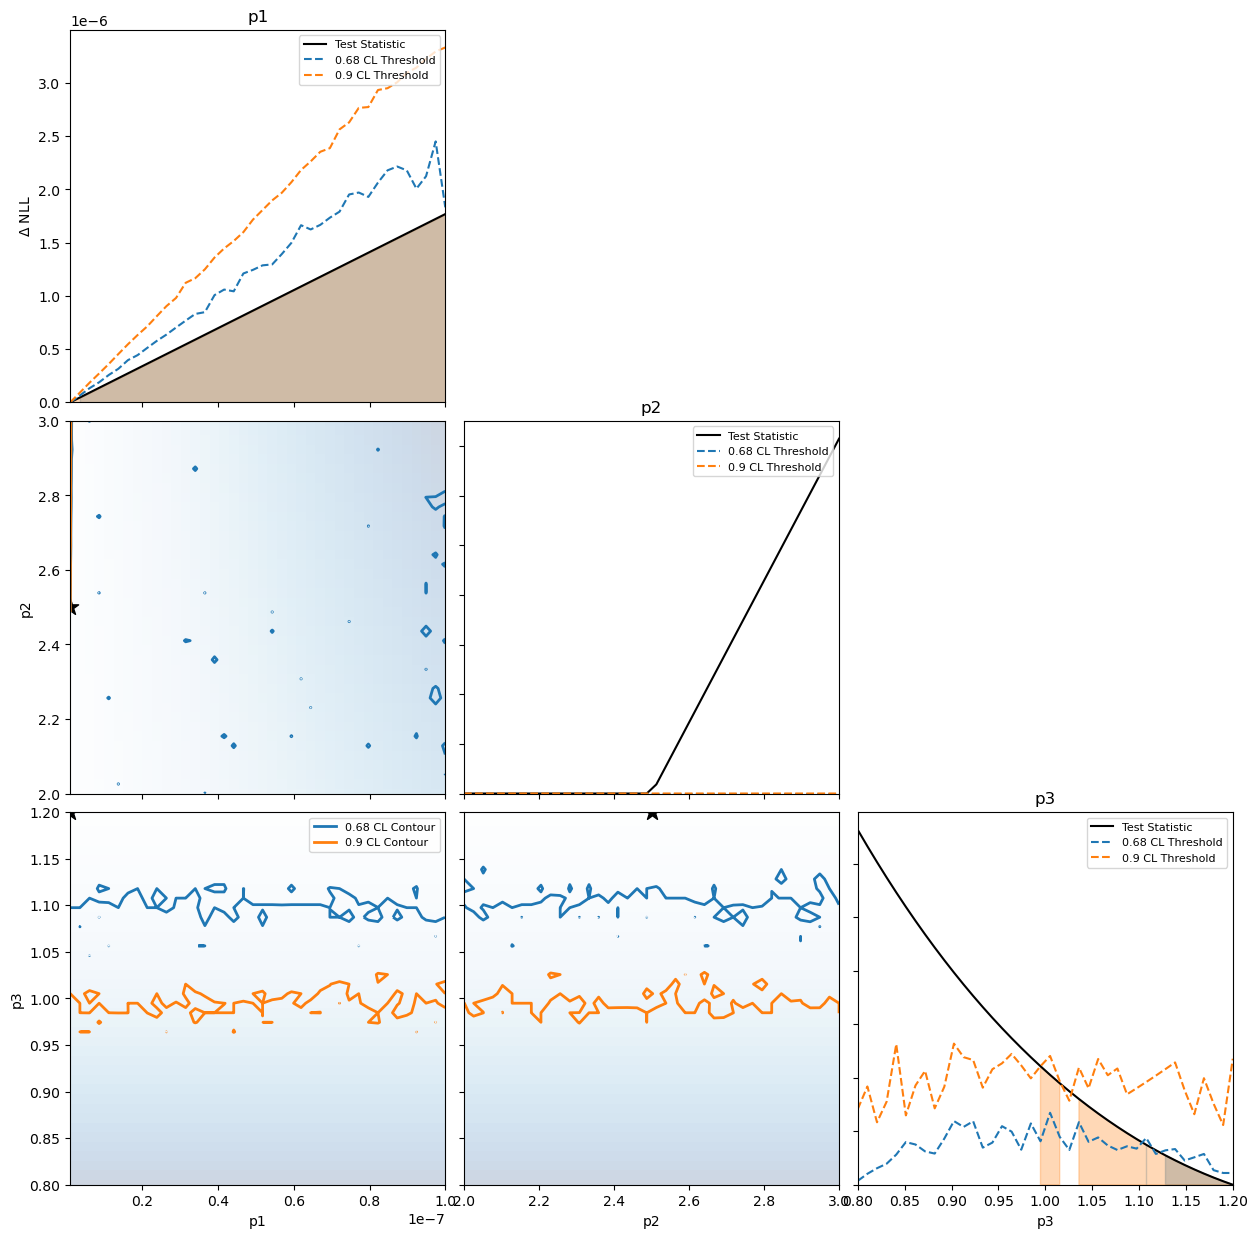

In [2]:
@njit(fastmath=True, nogil=True)
def my_compute_rates_binned(params, S_template, B_template, S_sigma2, B_sigma2):
    """ Maps parameters to expected counts (mu) and simulated variances (sigma2). """
    # params[0] = flux_norm, params[1] = spectral_index, params[2] = bg_norm
    mu = (params[0] * params[1]) * S_template + params[2] * B_template
    sigma2 = ((params[0] * params[1])**2) * S_sigma2 + (params[2]**2) * B_sigma2
    return mu, sigma2

# Setup Grids & Templates
grids_3p = [np.linspace(1e-9, 1e-7, 40), np.linspace(2.0, 3.0, 40), np.linspace(0.8, 1.2, 40)]
S_template = np.array([0.1, 0.5, 2.0, 5.0])
B_template = np.array([15.0, 5.0, 1.0, 0.1])
observed_counts = np.array([20, 7, 2, 0])

# Execute Binned Analysis
print("Running 3-Parameter Binned Analysis...")
results_binned, fig_binned = compute_fc_intervals( # <-- Unpacking updated tuple
    data=observed_counts,
    S_model=S_template,
    B_model=B_template,
    grids=grids_3p,
    compute_rates_func=my_compute_rates_binned,
    likelihood_type="binned",
    cl=[0.68, 0.90],
    n_toys=N_TOYS,
    num_cores=CORES,
    sparsify_grid=False,
    output_file="fc_results",
    param_names=["p1", "p2", "p3"],
    save_directory="fc_tutorial_output/binned"
)

print("\n--- Extracted Interval Bounds (Binned) ---")
print_bounds_from_disk("binned")

### 1B. Unbinned model
For unbinned data, we evaluate probability density functions directly on an event-by-event basis, and require a custom toy generator function to bootstrap synthetic datasets.

Running 3-Parameter Unbinned Analysis...
--- FC Construction Initiated (3-Parameter Model) ---
Modes -> 1D Intervals: True | 2D Intervals: True
Strategy: SCIPY | Cores: 10 | Likelihood: UNBINNED
Executing 1D Parameter Scans...


1D Toys (p1): 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:05<00:00,  7.23it/s]


Checkpoint successfully written mapping 1D parameter 1


1D Toys (p2): 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:05<00:00,  7.98it/s]


Checkpoint successfully written mapping 1D parameter 2


...

Checkpoint successfully written mapping 2D sector p1p2
Executing 2D Grid Scan mapping p1p3 (40x40)...


2D Edge p1p3: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1600/1600 [03:38<00:00,  7.34it/s]


Checkpoint successfully written mapping 2D sector p1p3
Executing 2D Grid Scan mapping p2p3 (40x40)...


2D Edge p2p3: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1600/1600 [03:37<00:00,  7.35it/s]


Checkpoint successfully written mapping 2D sector p2p3
Results archived completely to storage matrix fc_tutorial_output/unbinned/fc_results.npz and JSON fc_tutorial_output/unbinned/fc_results.json

--- Extracted Interval Bounds (Unbinned) ---
  param1:
    CL 0.68: ['9.4923e-08', '1.0000e-07']
    CL 0.9: ['9.4923e-08', '1.0000e-07']
  param2:
    CL 0.68: ['2.5128e+00', '3.0000e+00']
    CL 0.9: ['2.5128e+00', '3.0000e+00']
  param3:
    CL 0.68: ['1.1179e+00', '1.2000e+00']
    CL 0.9: ['1.1179e+00', '1.2000e+00']


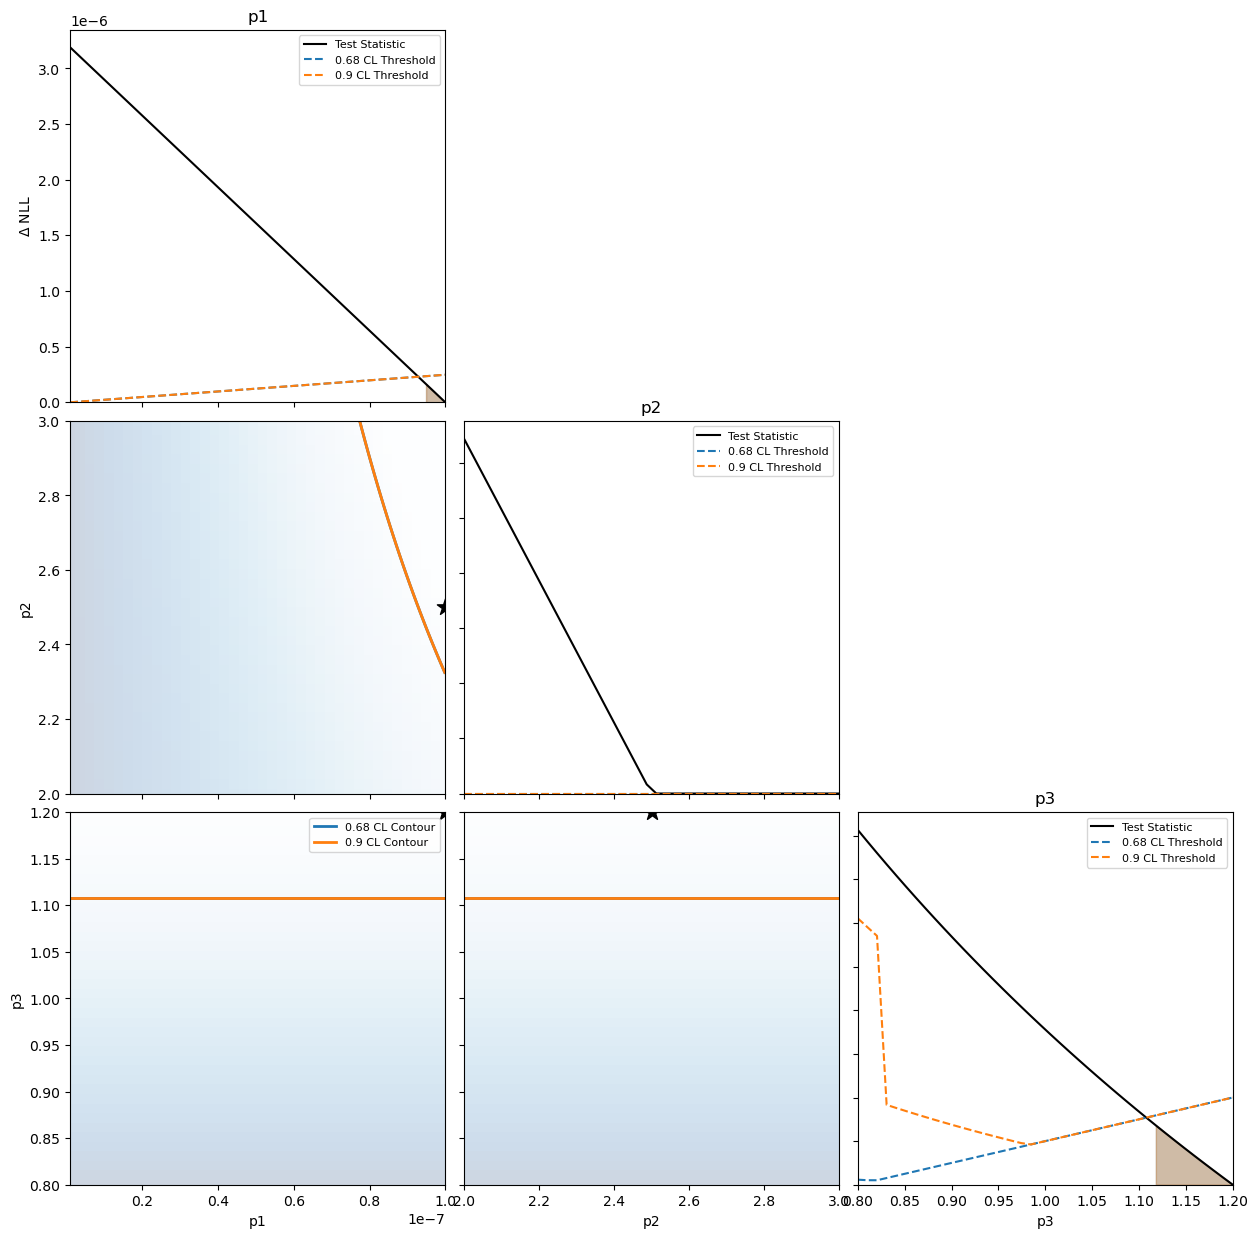

In [3]:
# PDF definitions
def s_pdf(x): return norm.pdf(x, loc=5.0, scale=1.0)
def b_pdf(x): return expon.pdf(x, scale=2.0)

def my_compute_rates_unbinned(params, s_probs, b_probs):
    """ Returns total expected integral and unnormalized per-event density. """
    expected_total = params[0] * params[1] + params[2]
    if len(s_probs) == 0 and len(b_probs) == 0:
        return expected_total, np.array([])
    p_events = params[0] * params[1] * s_probs + params[2] * b_probs
    return expected_total, p_events

def my_generate_unbinned_toy(true_params, S_mc_pool, B_mc_pool):
    """ Bootstraps event kinematics. """
    n_sig = np.random.poisson(true_params[0] * true_params[1])
    n_bkg = np.random.poisson(true_params[2])
    parts = []
    if n_sig > 0: parts.append(np.random.choice(S_mc_pool, size=n_sig, replace=True))
    if n_bkg > 0: parts.append(np.random.choice(B_mc_pool, size=n_bkg, replace=True))
    return np.concatenate(parts) if parts else np.array([])

# Mock Event Data
s_mc = np.random.normal(5.0, 1.0, 3000)
b_mc = np.random.exponential(2.0, 3000)
observed_events = np.concatenate([np.random.choice(s_mc, 3), np.random.choice(b_mc, 2)])

print("Running 3-Parameter Unbinned Analysis...")
results_unbinned, fig_unbinned = compute_fc_intervals( # <-- Unpacking updated tuple
    data=observed_events,
    S_model=s_pdf,
    B_model=b_pdf,
    grids=grids_3p, # Reusing the same grid scales
    compute_rates_func=my_compute_rates_unbinned,
    generate_toy_func=my_generate_unbinned_toy,
    likelihood_type="unbinned",
    S_mc_pool=s_mc,
    B_mc_pool=b_mc,
    cl=[0.68, 0.90],
    n_toys=N_TOYS,
    num_cores=CORES,
    sparsify_grid=False,
    output_file="fc_results",
    param_names=["p1", "p2", "p3"],
    save_directory="fc_tutorial_output/unbinned"
)

print("\n--- Extracted Interval Bounds (Unbinned) ---")
print_bounds_from_disk("unbinned")

---
## 2. Five-parameter case
PyFC dynamically adapts to $N$-dimensional space. Here we create a mock 5-parameter model. 

**Warning:** Calculating 2D contours for 5 parameters results in 10 unique joint combinations ($5 \times 4 / 2$). The code will take longer to finish.

Running 5-Parameter Binned Analysis (1D Only)...
--- FC Construction Initiated (5-Parameter Model) ---
Modes -> 1D Intervals: True | 2D Intervals: True
Strategy: SCIPY | Cores: 10 | Likelihood: BINNED
Executing 1D Parameter Scans...


1D Toys (p1): 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [00:34<00:00,  1.15s/it]


Checkpoint successfully written mapping 1D parameter 1


1D Toys (p2): 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [00:19<00:00,  1.51it/s]


Checkpoint successfully written mapping 1D parameter 2


...

Checkpoint successfully written mapping 2D sector p3p4
Executing 2D Grid Scan mapping p3p5 (30x30)...


2D Edge p3p5: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 900/900 [19:02<00:00,  1.27s/it]


Checkpoint successfully written mapping 2D sector p3p5
Executing 2D Grid Scan mapping p4p5 (30x30)...


2D Edge p4p5: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 900/900 [18:02<00:00,  1.20s/it]


Checkpoint successfully written mapping 2D sector p4p5
Results archived completely to storage matrix fc_tutorial_output/binned_5p/fc_results.npz and JSON fc_tutorial_output/binned_5p/fc_results.json

--- Extracted Interval Bounds ---
  param1:
    CL 0.68: ['5.0100e-01', '5.0100e-01']
    CL 0.9: ['5.0100e-01', '5.0100e-01']
  param2:
    CL 0.68: ['9.1397e-01', '1.4302e+00']
    CL 0.9: ['8.1072e-01', '1.4990e+00']
  param3:
    CL 0.68: ['5.0100e-01', '5.3541e-01']
    CL 0.9: ['5.0100e-01', '1.3613e+00']
  param4:
    CL 0.68: ['5.0100e-01', '5.0100e-01']
    CL 0.9: ['5.0100e-01', '9.8279e-01']
  param5:
    CL 0.68: ['5.0100e-01', '5.3541e-01']
    CL 0.9: ['5.0100e-01', '8.1072e-01']


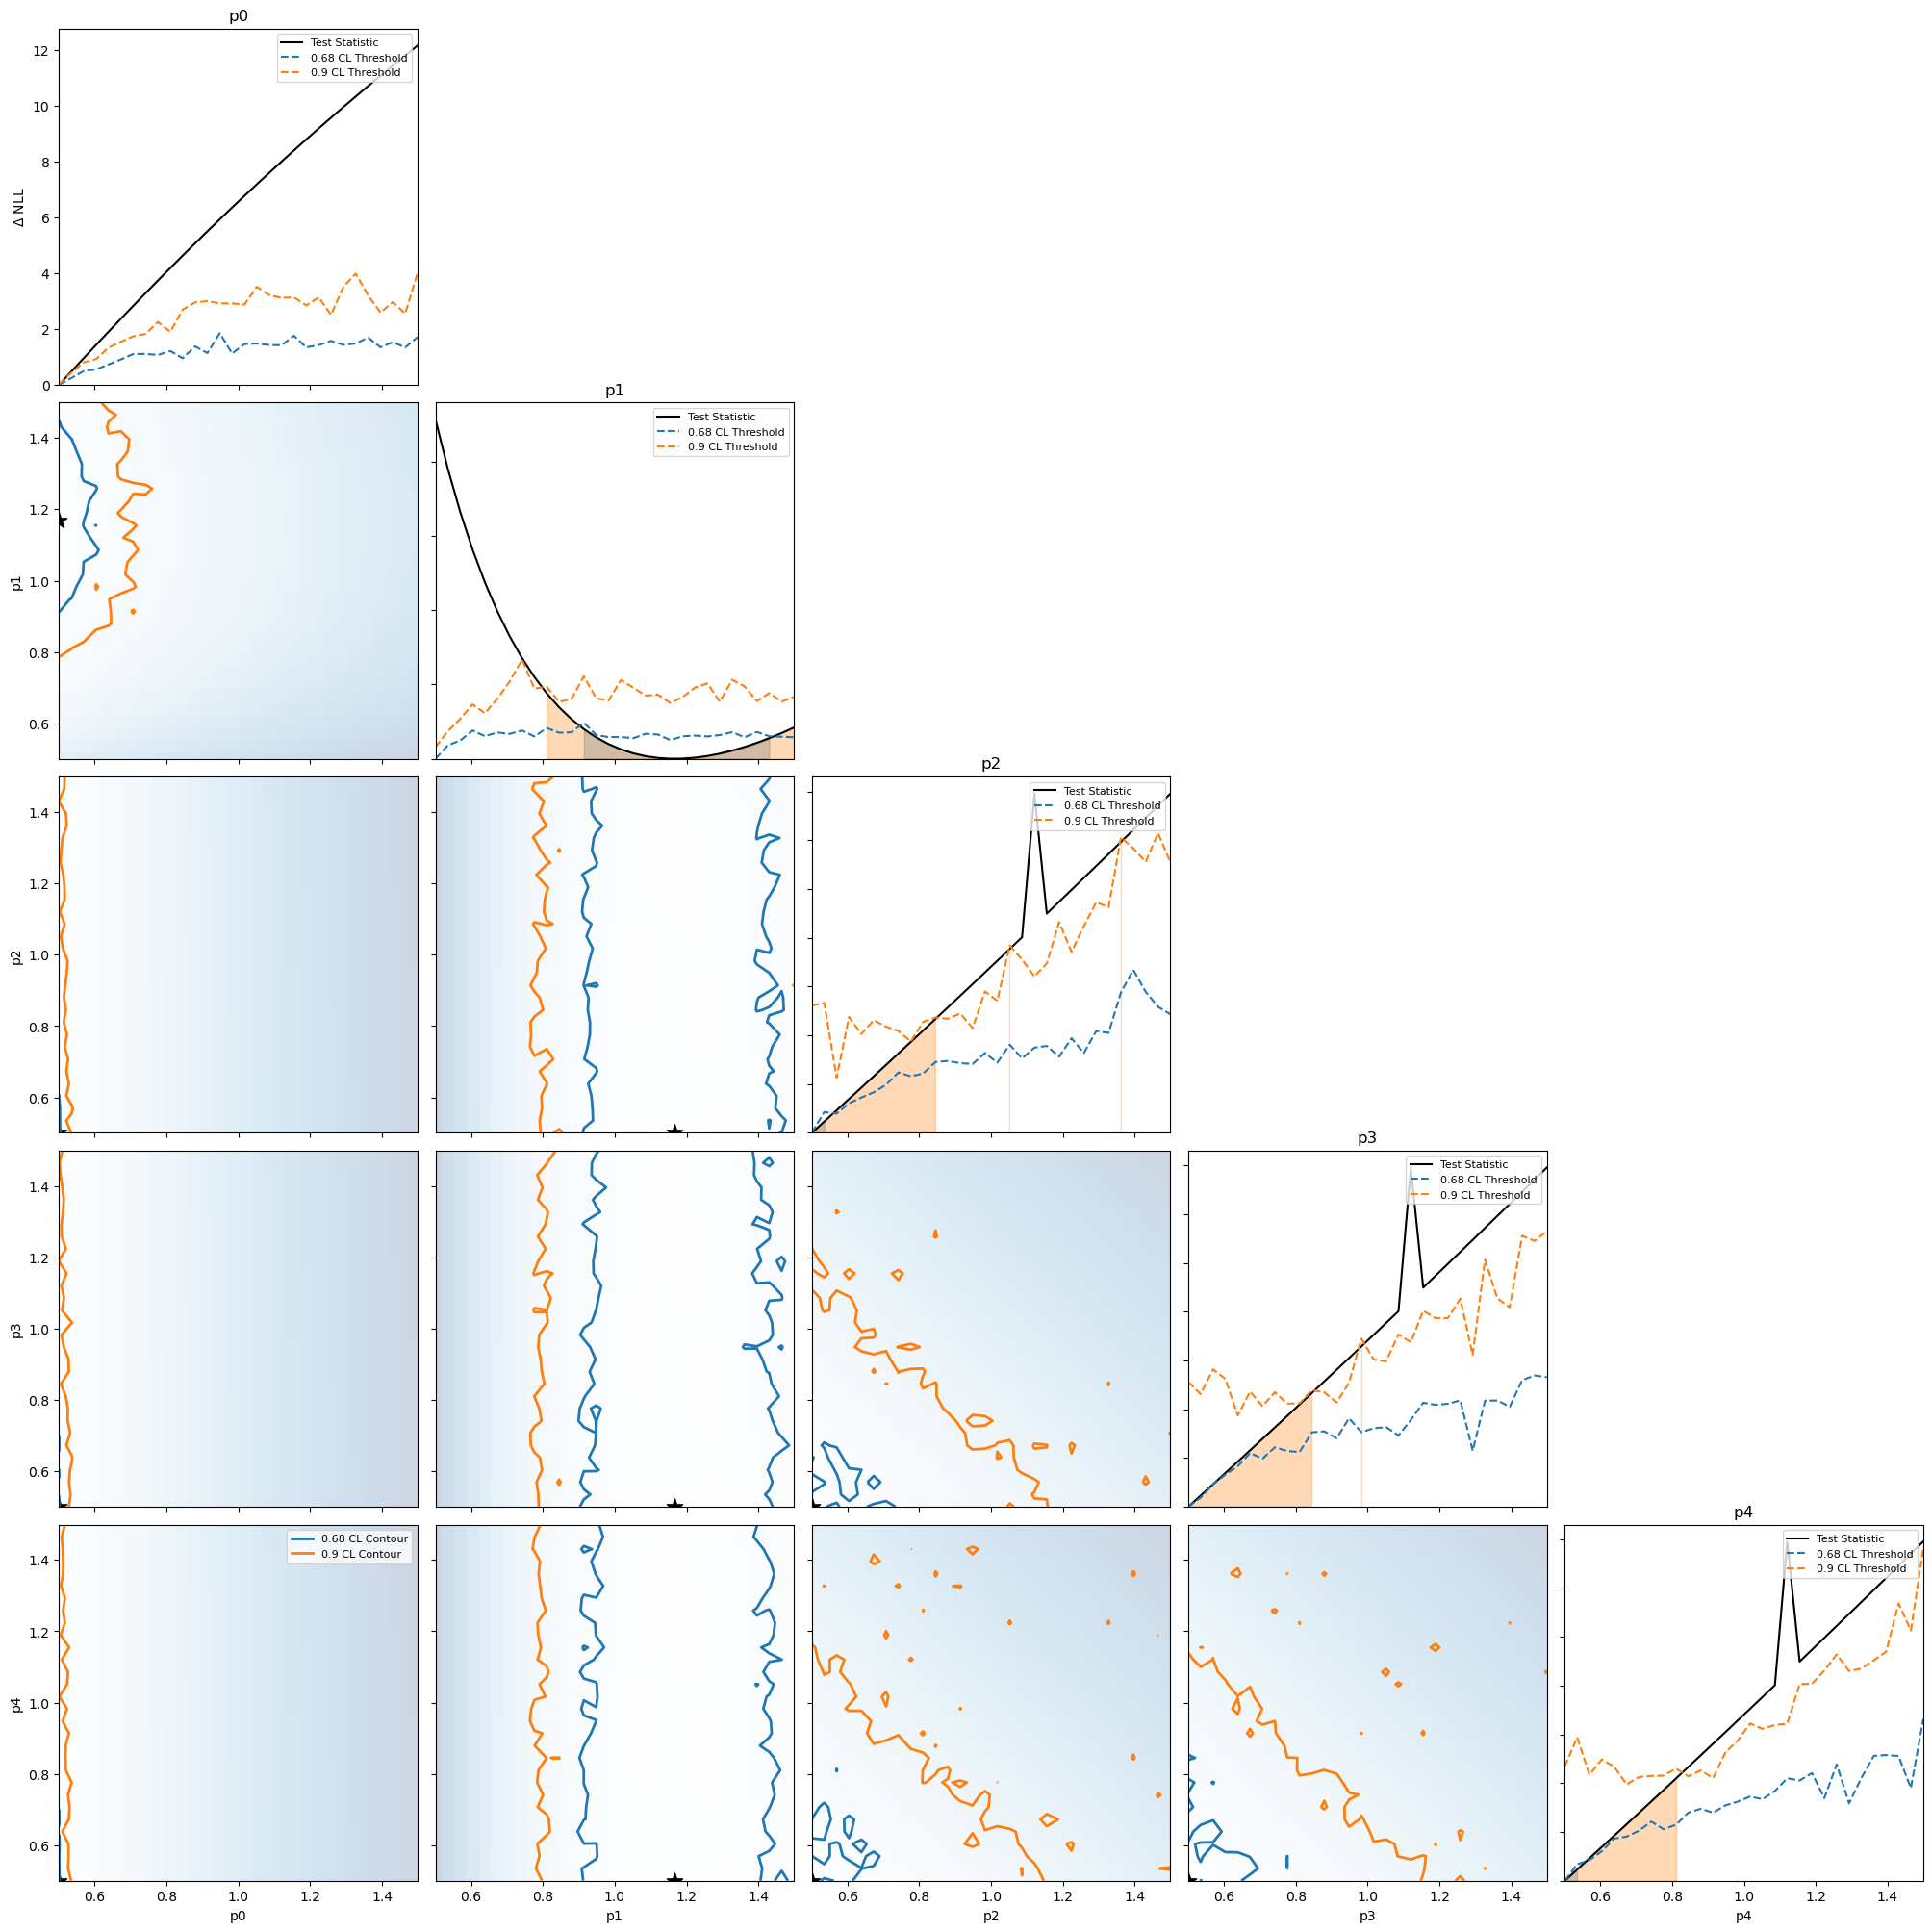

In [3]:
S_template = np.array([0.1, 0.5, 2.0, 5.0, 3.0, 1.0])
B_template = np.array([15.0, 5.0, 1.0, 0.1, 0.05, 0.01])
observed_counts = np.array([20, 7, 2, 0, 1, 0])

# Compute S_sigma2 and B_sigma2 properly as the sum of squared MC weights (sum(w^2)).
# In practice, if you generate these from an MC event pool with weights, you do:
#   S_sigma2, _ = np.histogram(mc_values, bins=bin_edges, weights=mc_weights**2)
# For this tutorial example, we represent the sum of squared weights explicitly:
S_sigma2 = S_template * 1.1  # Example factoring in weight variance (sum(w^2))
B_sigma2 = B_template * 0.9  # Example factoring in weight variance (sum(w^2))

@njit(fastmath=True, nogil=True)
def compute_rates_5p(params, S_temp, B_temp, S_sig2, B_sig2):
    # Primary parameters mapping to templates
    mu = params[0] * S_temp + params[1] * B_temp
    
    # 3 auxiliary parameters (e.g., systematic nuisance parameters)
    for i in range(2, 5):
        mu += params[i] * 0.05 
        
    # Calculate template variance using the sum of squared weights (S_sig2, B_sig2)
    sigma2 = (params[0]**2) * S_sig2 + (params[1]**2) * B_sig2
        
    return mu, sigma2

# Create 5 independent grids of 10 evaluation points each
grids_5p = [np.linspace(0.501, 1.499, 30) for _ in range(5)]

print("Running 5-Parameter Binned Analysis (1D Only)...")
results_5p, fig_5p = compute_fc_intervals(
    data=observed_counts,
    S_model=S_template,
    B_model=B_template,
    grids=grids_5p,
    compute_rates_func=compute_rates_5p,
    likelihood_type="binned",
    cl=[0.68, 0.90],
    n_toys=N_TOYS,
    num_cores=CORES,
    compute_1D_intervals=True,
    compute_2D_intervals=True, 
    sparsify_grid=False,
    param_names=[f"p{i}" for i in range(5)],
    output_file="fc_results",
    save_directory="fc_tutorial_output/binned_5p",
    S_sigma2=S_sigma2,
    B_sigma2=B_sigma2
)

print("\n--- Extracted Interval Bounds ---")
print_bounds_from_disk("binned_5p")

---
## 3. Algorithmic enhancements: sparsification vs. no sparsification
To calculate exact 2D contours, PyFC has to evaluate pseudo-experiments across a 2D mesh grid. 
*   **`sparsify_grid = False`**: Calculates MC toys at every single node. Highly accurate but very slow. Default choice.
*   **`sparsify_grid = True`**: Uses an edge-tracing heuristic to only evaluate toys on the exact boundary of the contour, skipping the deep interior and far exterior nodes.

Let's compare the execution time on our 3-parameter binned model.

--- Running WITHOUT Sparsification ---
--- FC Construction Initiated (3-Parameter Model) ---
Modes -> 1D Intervals: True | 2D Intervals: True
Strategy: SCIPY | Cores: 10 | Likelihood: BINNED
Executing 1D Parameter Scans...


1D Toys (p1): 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:06<00:00,  3.13it/s]


Checkpoint successfully written mapping 1D parameter 1


1D Toys (p2): 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:06<00:00,  3.04it/s]


Checkpoint successfully written mapping 1D parameter 2


...

Checkpoint successfully written mapping 2D sector p1p3
Executing 2D Grid Scan mapping p2p3 (20x20)...
2D Sparsification: Coarse array pass across 36 structural points...


2D Coarse p2p3: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 36/36 [00:08<00:00,  4.13it/s]


2D Sparsification: Boundary resolved. Integrating 110 exact refinement matrices...


2D Edge p2p3: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 110/110 [00:00<00:00, 187473.97it/s]


Checkpoint successfully written mapping 2D sector p2p3
Results archived completely to storage matrix fc_tutorial_output/binned_sparse_on/fc_results.npz and JSON fc_tutorial_output/binned_sparse_on/fc_results.json
Time with sparsification: 47.11 seconds
Speedup Factor: 7.31x

--- Verify Bounds Match ---
Unsparsified Bounds:
Could not find fc_tutorial_output/binned_no_sparse/fc_results.json

Sparsified Bounds:
Could not find fc_tutorial_output/binned_with_sparse/fc_results.json


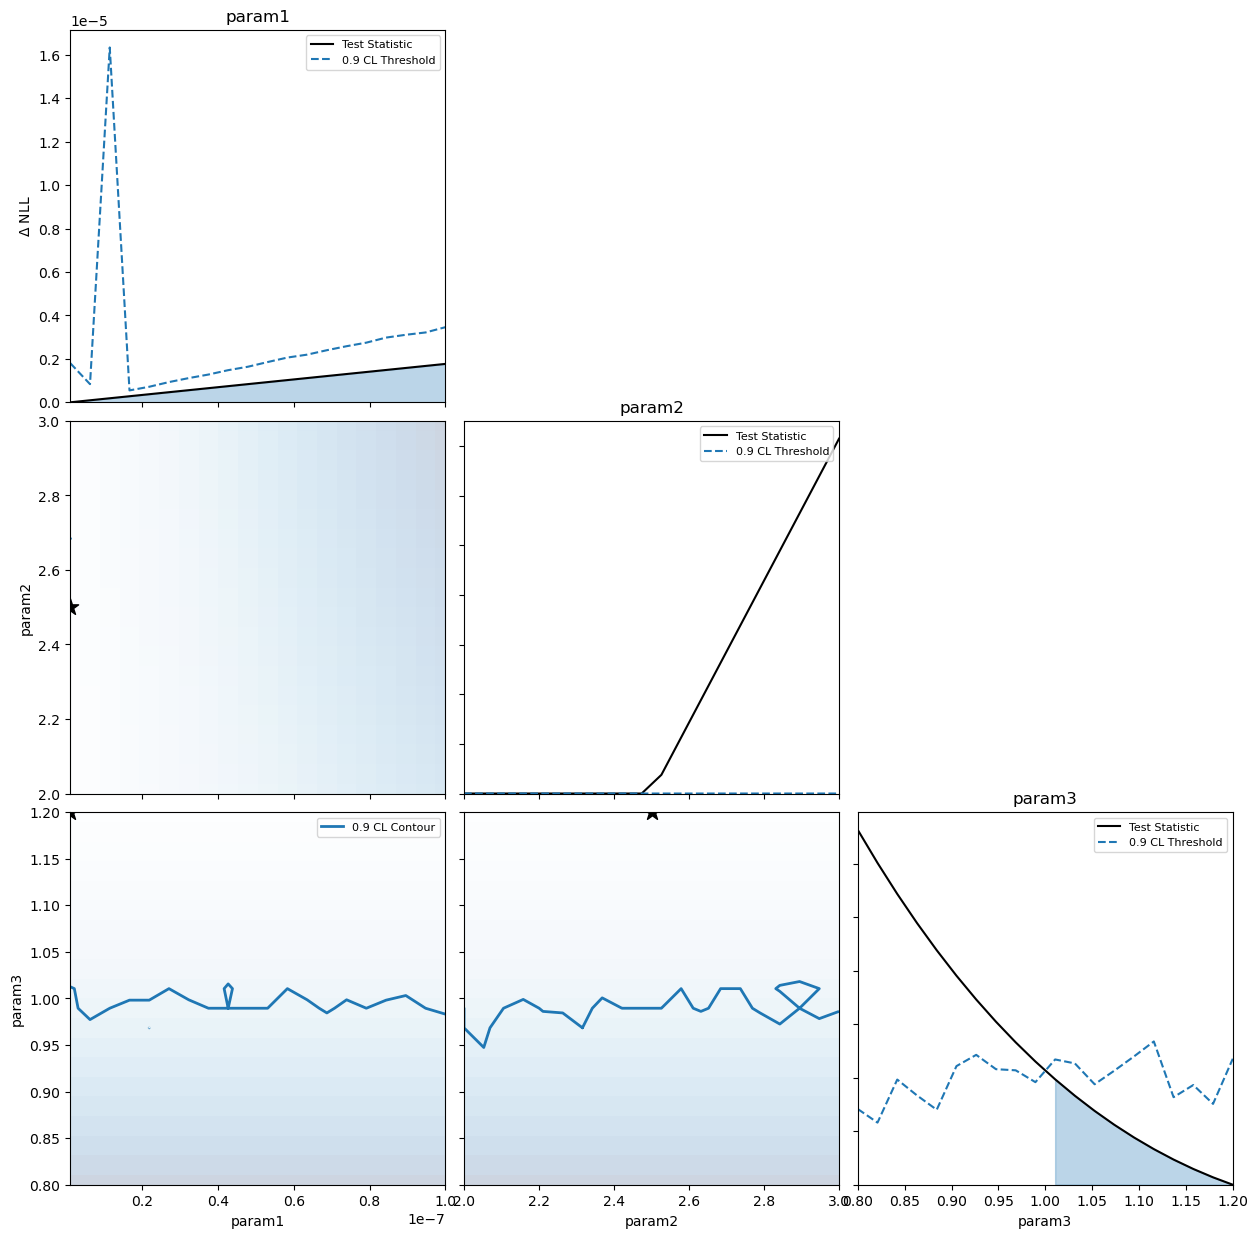

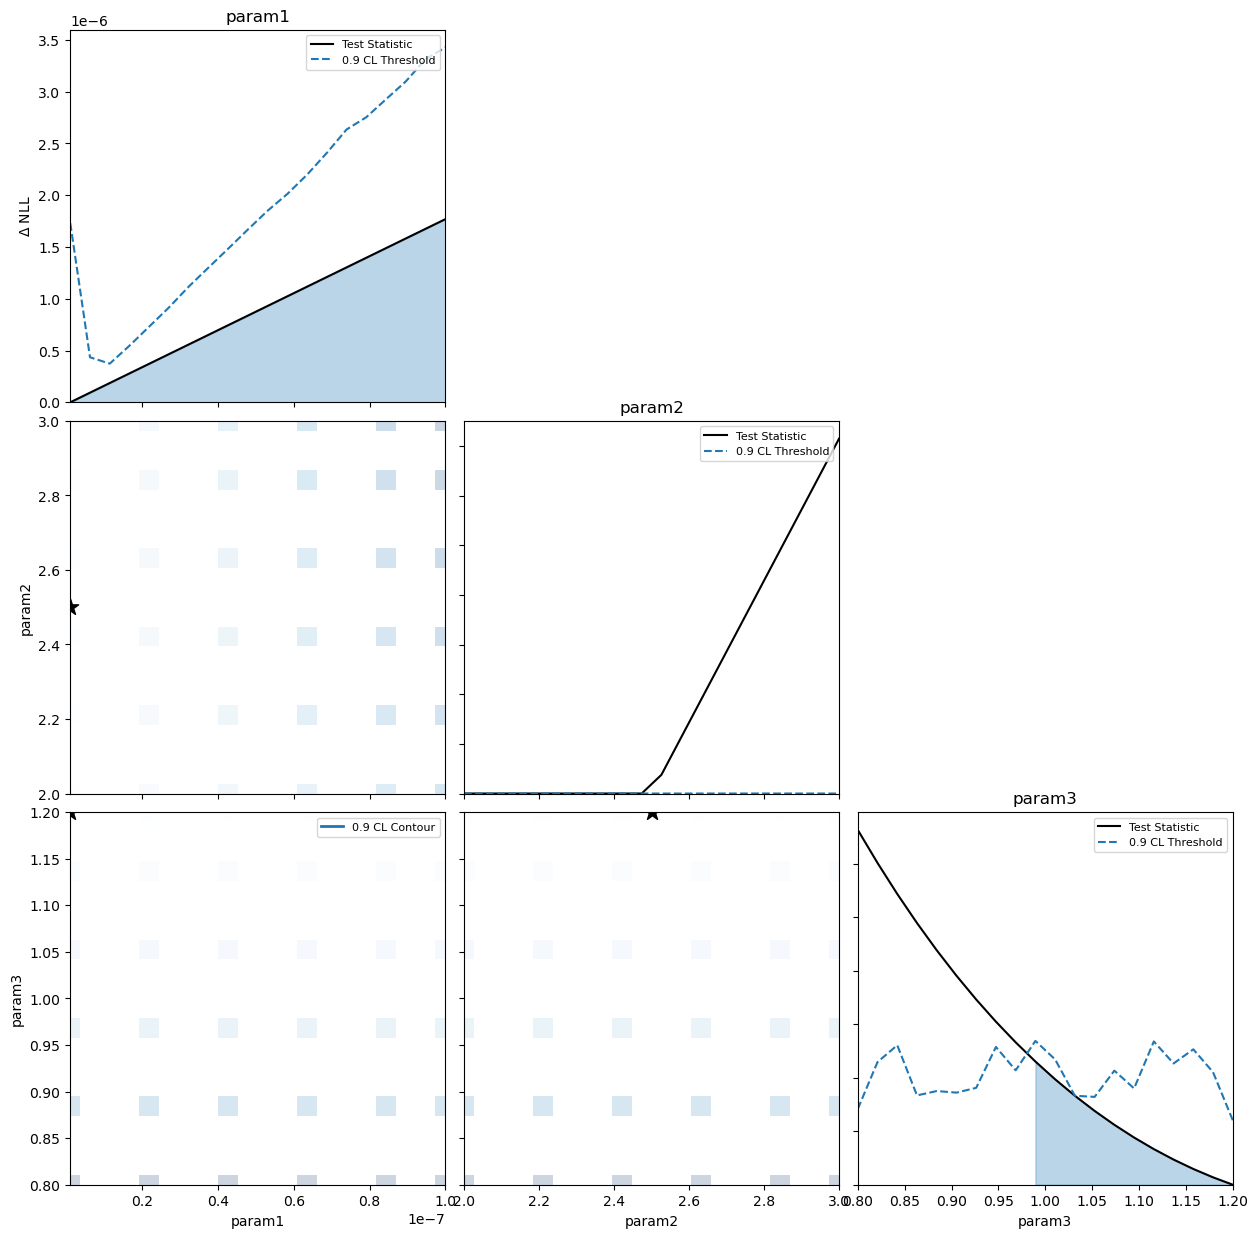

In [4]:
@njit(fastmath=True, nogil=True)
def my_compute_rates_binned(params, S_template, B_template, S_sigma2, B_sigma2):
    """ Maps parameters to expected counts (mu) and simulated variances (sigma2). """
    # params[0] = flux_norm, params[1] = spectral_index, params[2] = bg_norm
    mu = (params[0] * params[1]) * S_template + params[2] * B_template
    sigma2 = ((params[0] * params[1])**2) * S_sigma2 + (params[2]**2) * B_sigma2
    return mu, sigma2

# Setup Grids & Templates
S_template = np.array([0.1, 0.5, 2.0, 5.0])
B_template = np.array([15.0, 5.0, 1.0, 0.1])
observed_counts = np.array([20, 7, 2, 0])

# Redefining a slightly tighter grid for a fair speed comparison
grids_dense = [np.linspace(1e-9, 1e-7, 20), np.linspace(2.0, 3.0, 20), np.linspace(0.8, 1.2, 20)]

print("--- Running WITHOUT Sparsification ---")
t0 = time.time()
res_no_sparse, _ = compute_fc_intervals( # <-- Using underscore for unused plot
    data=observed_counts, S_model=S_template, B_model=B_template, grids=grids_dense,
    compute_rates_func=my_compute_rates_binned,
    sparsify_grid=False, n_toys=N_TOYS, num_cores=CORES, save_log=False,
    output_file="fc_results", save_directory="fc_tutorial_output/binned_sparse_off"
)
t1 = time.time()
print(f"Time without sparsification: {t1 - t0:.2f} seconds")

print("\n--- Running WITH Sparsification ---")
t2 = time.time()
res_sparse, _ = compute_fc_intervals( # <-- Using underscore for unused plot
    data=observed_counts, S_model=S_template, B_model=B_template, grids=grids_dense,
    compute_rates_func=my_compute_rates_binned,
    sparsify_grid=True, n_toys=N_TOYS, num_cores=CORES, save_log=False,
    output_file="fc_results", save_directory="fc_tutorial_output/binned_sparse_on"
)
t3 = time.time()
print(f"Time with sparsification: {t3 - t2:.2f} seconds")
print(f"Speedup Factor: {(t1 - t0) / (t3 - t2):.2f}x")

print("\n--- Verify Bounds Match ---")
print("Unsparsified Bounds:")
print_bounds_from_disk("binned_no_sparse")
print("\nSparsified Bounds:")
print_bounds_from_disk("binned_with_sparse")

---
## 4. Visual polish: smoothing vs. no smoothing
By default, the 1D profiles and 2D contours can appear jagged if your grid resolution is low. PyFC includes a plotting module that can apply a Gaussian filter to the underlying test statistic surfaces to produce publication-ready smoothed contours.

Instead of re-running the heavy MC generation, we will pass the `results` dictionary we generated earlier directly into the plotting function with different configurations.

--- Unsmoothed Contours ---

--- Smoothed Contours ---


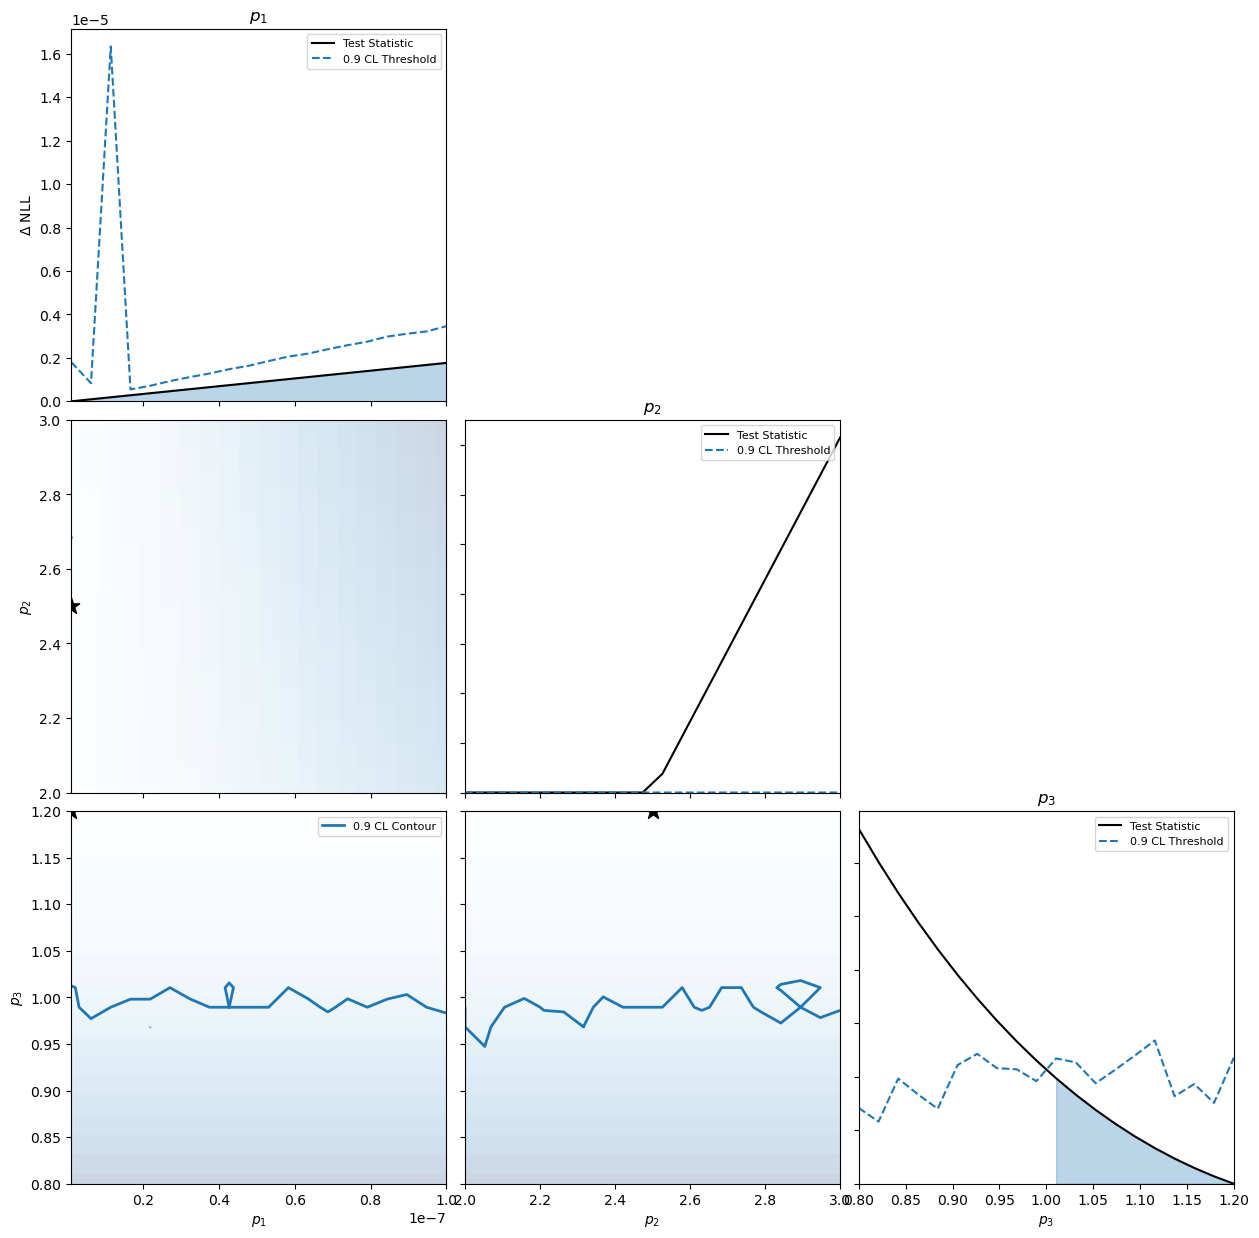

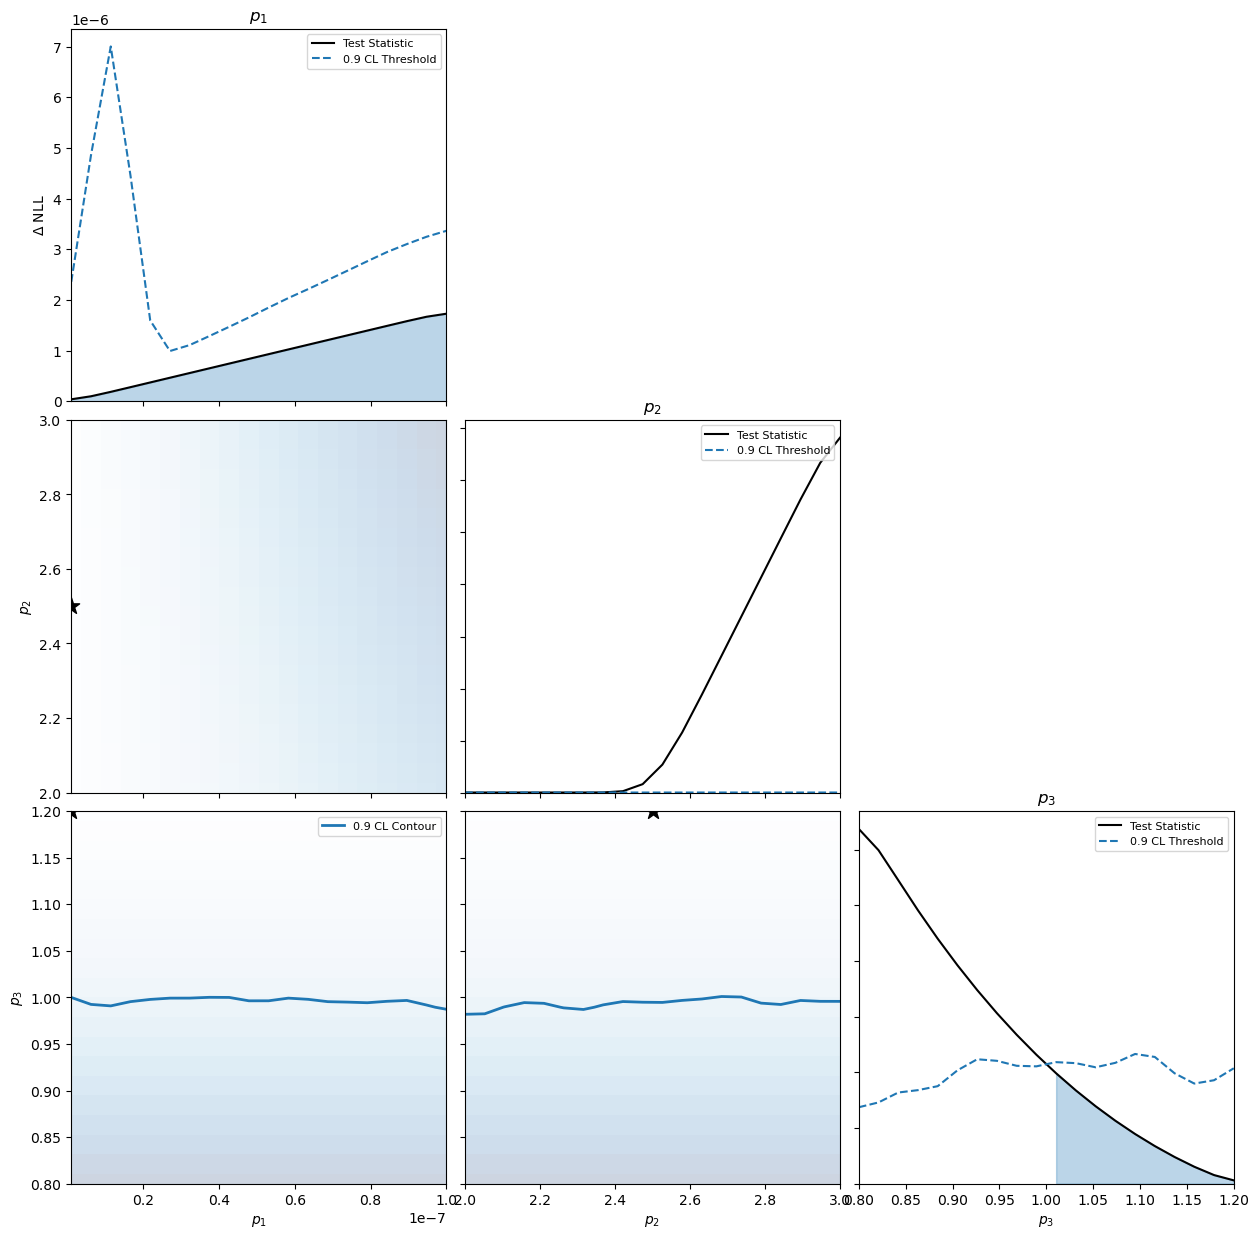

In [7]:
# Common plotting setup
plot_config = {
    "n_params": 3,
    "compute_1D_intervals": True,
    "compute_2D_intervals": True,
    "param_names": [r"$p_1$", r"$p_2$", r"$p_3$"], # LaTeX support!
    "cl": [0.90]
}


# 1. Generate Raw (Unsmoothed) Plot
print("--- Unsmoothed Contours ---")
plot_config_unsmoothed = plot_config.copy()
plot_config_unsmoothed["smooth_1d"] = False
plot_config_unsmoothed["smooth_2d"] = False
plot_config_unsmoothed["save_directory"] = "fc_tutorial_output/unsmoothed"
os.makedirs(plot_config_unsmoothed["save_directory"], exist_ok=True)

fig_unsmoothed = generate_corner_plot(res_no_sparse, plot_config_unsmoothed) # <-- Capture the returned fig

# 2. Generate Smoothed Plot
print("\n--- Smoothed Contours ---")
plot_config_smoothed = plot_config.copy()
plot_config_smoothed["smooth_1d"] = True
plot_config_smoothed["smooth_2d"] = True
plot_config_smoothed["save_directory"] = "fc_tutorial_output/smoothed"
os.makedirs(plot_config_smoothed["save_directory"], exist_ok=True)

fig_smoothed = generate_corner_plot(res_no_sparse, plot_config_smoothed) # <-- Capture the returned fig


---
## 5. Statistical rigor: the finite MC correction
If your templates (`S_template`, `B_template`) were generated using Monte Carlo simulations with low statistics, treating them as exact truths results in over-constrained, artificially tight confidence intervals. 

PyFC can correct this by treating the expectations as Poisson-Gamma mixtures. Here, we inject massively inflated uncertainties (`S_sigma2`, `B_sigma2`) into the model to demonstrate how the framework widens the confidence regions to protect statistical coverage.

--- Running WITH Finite MC Correction ---
--- FC Construction Initiated (3-Parameter Model) ---
Modes -> 1D Intervals: True | 2D Intervals: True
Strategy: SCIPY | Cores: 10 | Likelihood: BINNED
Executing 1D Parameter Scans...


1D Toys (p1): 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:02<00:00,  6.91it/s]


Checkpoint successfully written mapping 1D parameter 1


1D Toys (p2): 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:03<00:00,  6.09it/s]


Checkpoint successfully written mapping 1D parameter 2


...

Checkpoint successfully written mapping 2D sector p1p2
Executing 2D Grid Scan mapping p1p3 (20x20)...


2D Edge p1p3: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 400/400 [01:42<00:00,  3.89it/s]


Checkpoint successfully written mapping 2D sector p1p3
Executing 2D Grid Scan mapping p2p3 (20x20)...


2D Edge p2p3: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 400/400 [01:43<00:00,  3.88it/s]


Checkpoint successfully written mapping 2D sector p2p3
Results archived completely to storage matrix fc_tutorial_output/finite_mc_correction_off/fc_results.npz and JSON fc_tutorial_output/finite_mc_correction_off/fc_results.json

--- Compare Resulting Intervals ---
Intervals WITHOUT Correction (Overconfident):
  param1:
    CL 0.9: ['1.0000e-09', '1.0000e-07']
  param2:
    CL 0.9: ['2.0000e+00', '2.4737e+00']
  param3:
    CL 0.9: ['9.8947e-01', '1.2000e+00']

Intervals WITH Correction (Conservative):
  param1:
    CL 0.9: ['1.0000e-07', '1.0000e-07']
  param2:
    CL 0.9: ['2.5263e+00', '3.0000e+00']
  param3:
    CL 0.9: ['8.2105e-01', '1.2000e+00']


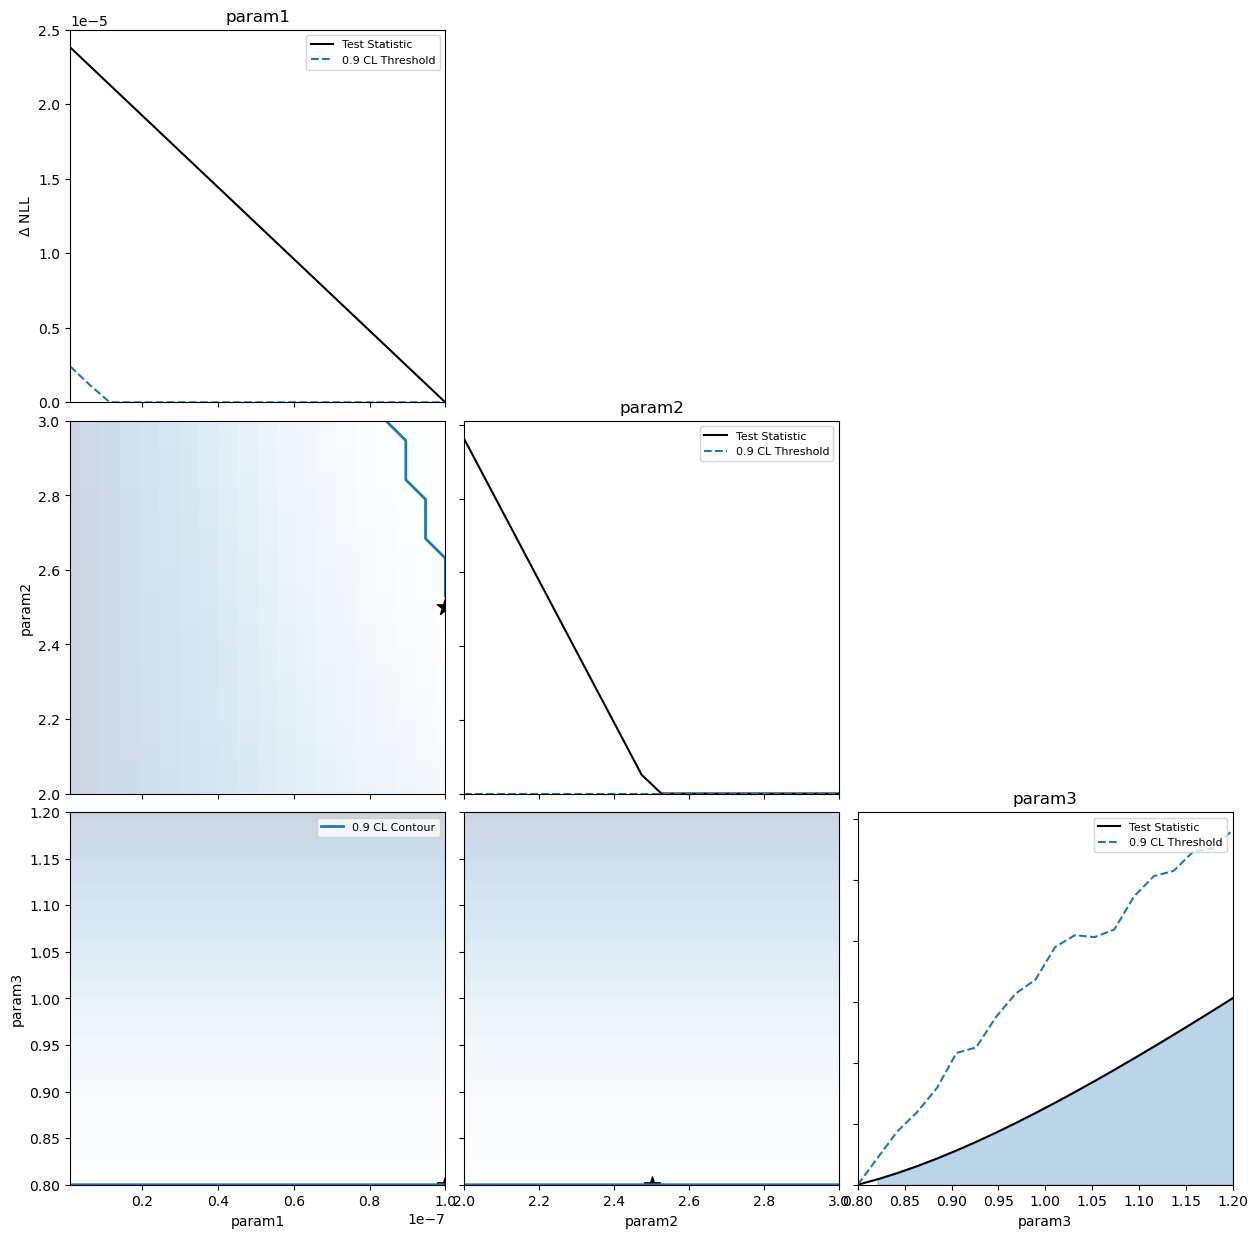

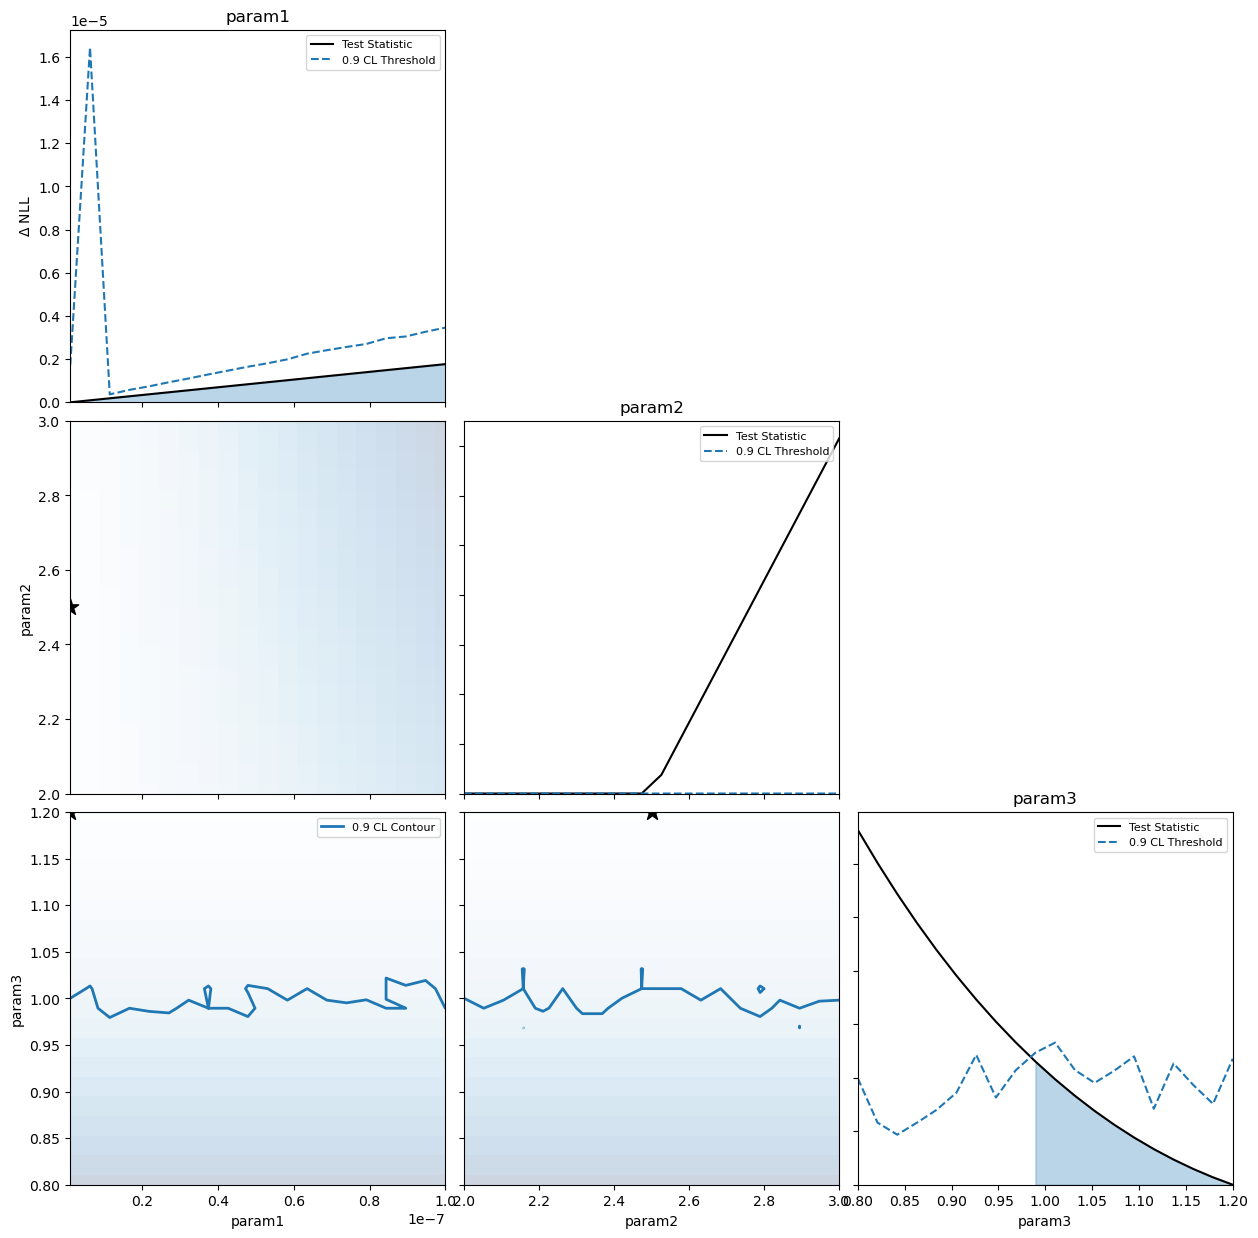

In [8]:
@njit(fastmath=True, nogil=True)
def my_compute_rates_binned(params, S_template, B_template, S_sigma2, B_sigma2):
    """ Maps parameters to expected counts (mu) and simulated variances (sigma2). """
    # params[0] = flux_norm, params[1] = spectral_index, params[2] = bg_norm
    mu = (params[0] * params[1]) * S_template + params[2] * B_template
    sigma2 = ((params[0] * params[1])**2) * S_sigma2 + (params[2]**2) * B_sigma2
    return mu, sigma2

# Setup Grids & Templates
S_template = np.array([0.1, 0.5, 2.0, 5.0])
B_template = np.array([15.0, 5.0, 1.0, 0.1])
observed_counts = np.array([20, 7, 2, 0])

# Redefining a slightly tighter grid for a fair speed comparison
grids_dense = [np.linspace(1e-9, 1e-7, 20), np.linspace(2.0, 3.0, 20), np.linspace(0.8, 1.2, 20)]

# Inflate uncertainties to heavily penalize the likelihood
massive_S_sigma2 = S_template * 5.0
massive_B_sigma2 = B_template * 5.0

print("--- Running WITH Finite MC Correction ---")
# Because uncertainty is accounted for, intervals will be appropriately wider and more conservative.
res_finite_mc, _ = compute_fc_intervals( # <-- Using underscore for unused plot
    data=observed_counts, S_model=S_template, B_model=B_template, grids=grids_dense,
    compute_rates_func=my_compute_rates_binned,
    S_sigma2=massive_S_sigma2, B_sigma2=massive_B_sigma2,
    use_finite_mc_correction_binned=True, # Active
    n_toys=N_TOYS, num_cores=CORES, save_log=False, sparsify_grid=False,
    output_file="fc_results", save_directory="fc_tutorial_output/finite_mc_correction_on"
)

print("\n--- Running WITHOUT Finite MC Correction ---")
# The framework ignores the huge template variances, leading to overconfidence.
res_no_finite_mc, _ = compute_fc_intervals( # <-- Using underscore for unused plot
    data=observed_counts, S_model=S_template, B_model=B_template, grids=grids_dense,
    compute_rates_func=my_compute_rates_binned,
    S_sigma2=massive_S_sigma2, B_sigma2=massive_B_sigma2,
    use_finite_mc_correction_binned=False, # Ignored
    n_toys=N_TOYS, num_cores=CORES, save_log=False, sparsify_grid=False,
    output_file="fc_results", save_directory="fc_tutorial_output/finite_mc_correction_off"
)

print("\n--- Compare Resulting Intervals ---")
print("Intervals WITHOUT Correction (Overconfident):")
print_bounds_from_disk("finite_mc_correction_off")

print("\nIntervals WITH Correction (Conservative):")
print_bounds_from_disk("finite_mc_correction_on")

# 6. Strategy comparison

This exampels sets up a 3-parameter model and runs a loop to evaluate and compare the `scipy`, `grid`, and `hybrid` strategies. It  generates 2D intervals so the `.npz` files are written to disk for the next example.

In [2]:
import time

import numpy as np

from pyfc.optimizers import ULTRANEST_AVAILABLE

# =====================================================================
# 1. Base Model Setup
# =====================================================================
S_template = np.array([0.1, 0.5, 2.0, 5.0])
B_template = np.array([15.0, 5.0, 1.0, 0.1])
observed_counts = np.array([20, 7, 2, 0])
cl_to_test = [0.68, 0.90]

# =====================================================================
# 2. 3-Parameter Setup & Execution
# =====================================================================
@njit(fastmath=True, nogil=True)
def compute_rates_3p(params, S_temp, B_temp, S_sig2, B_sig2):
    # params[0] = S_norm, params[1] = B_norm, params[2] = sys_1
    mu = params[0] * S_temp + params[1] * B_temp
    mu += params[2] * 0.05
    return mu, np.zeros_like(mu)

# Create 3 independent grids of 10 evaluation points each
grids_3p = [np.linspace(0.5, 1.5, 20) for _ in range(3)]
param_names_3p = ["S_norm", "B_norm", "sys_1"]
strategies_to_test_3p = ["grid", "scipy", "hybrid"]
if ULTRANEST_AVAILABLE:
    strategies_to_test_3p.append("ultranest")
    
print("--- Strategy Comparison: 3-Parameter Binned Model ---")

for strat in strategies_to_test_3p:
    print(f"\nEvaluating Strategy: {strat.upper()}")
    start_time = time.time()
    
    save_dir = f"fc_tutorial_output/compare_{strat}"
    
    _, fig = compute_fc_intervals(
        data=observed_counts,
        S_model=S_template,
        B_model=B_template,
        grids=grids_3p,
        compute_rates_func=compute_rates_3p,
        likelihood_type="binned",
        cl=cl_to_test,
        n_toys=N_TOYS,
        num_cores=CORES,
        compute_1D_intervals=True,
        compute_2D_intervals=True, # Required to export the .npz files
        param_names=param_names_3p,
        sparsify_grid=(strat == "grid"),
        output_file="fc_results",
        save_directory=save_dir,
        verbose=0
    )
    
    # Suppress the figure from rendering in the notebook output
    if fig is not None:
        plt.close(fig)
        
    elapsed = time.time() - start_time
    print(f"Time taken ({strat}): {elapsed:.2f} seconds")
    
    print(f"Interval Bounds ({strat}):")
    print_bounds_from_disk(f"compare_{strat}")

# =====================================================================
# 3. 10-Parameter Setup & Execution (FIXED)
# =====================================================================

# 1. Expand the templates to have enough bins to constrain 10 parameters
S_template_10p = np.linspace(0.1, 5.0, 15)
B_template_10p = np.linspace(15.0, 0.1, 15)

# Generate mock data for the 15 bins
np.random.seed(42)
observed_counts_10p = np.random.poisson(S_template_10p + B_template_10p)

@njit(fastmath=True, nogil=True)
def compute_rates_10p(params, S_temp, B_temp, S_sig2, B_sig2):
    mu = params[0] * S_temp + params[1] * B_temp
    
    # 2. Break the degeneracy: Give each parameter a unique structural shape across the bins
    # We use a polynomial basis so each parameter modifies the spectrum uniquely
    base_shape = np.linspace(0.1, 1.0, len(S_temp))
    for i in range(2, 10):
        # i starts at 2, so the exponent shifts from 1 to 8
        unique_modifier = base_shape ** (i - 1)
        mu += params[i] * 0.05 * unique_modifier
        
    return mu, np.zeros_like(mu)

# Create 10 independent grids of 20 evaluation points each
grids_10p = [np.linspace(0.5, 1.5, 20) for _ in range(10)]
param_names_10p = ["S_norm", "B_norm"] + [f"sys_{i}" for i in range(1, 9)]

# "grid" is intentionally excluded to avoid an Out-of-Memory crash 
strategies_to_test_10p = ["scipy", "hybrid"]
if ULTRANEST_AVAILABLE:
    strategies_to_test_10p.append("ultranest")

print("\n--- Strategy Comparison: 10-Parameter Binned Model ---")

for strat in strategies_to_test_10p:
    print(f"\nEvaluating Strategy: {strat.upper()}")
    start_time = time.time()
    
    save_dir = f"fc_tutorial_output/compare_10p_{strat}"
    
    _, fig = compute_fc_intervals(
        data=observed_counts_10p,           # <-- Use the expanded data
        S_model=S_template_10p,             # <-- Use the expanded template
        B_model=B_template_10p,             # <-- Use the expanded template
        grids=grids_10p,
        compute_rates_func=compute_rates_10p,
        likelihood_type="binned",
        cl=cl_to_test,
        n_toys=3, 
        num_cores=CORES,
        compute_1D_intervals=True,
        compute_2D_intervals=False, 
        param_names=param_names_10p,
        sparsify_grid=False,
        output_file="fc_results",
        save_directory=save_dir,
        verbose=0
    )
    
    if fig is not None:
        plt.close(fig)
        
    elapsed = time.time() - start_time
    print(f"Time taken ({strat} 10p): {elapsed:.2f} seconds")
    print(f"Interval Bounds ({strat} 10p):")
    print_bounds_from_disk(f"compare_10p_{strat}")

--- Strategy Comparison: 3-Parameter Binned Model ---

Evaluating Strategy: GRID
Time taken (grid): 73.74 seconds
Interval Bounds (grid):
  param1:
    CL 0.68: ['5.0000e-01', '5.0000e-01']
    CL 0.9: ['5.0000e-01', '6.0526e-01']
  param2:
    CL 0.68: ['1.1316e+00', '1.4474e+00']
    CL 0.9: ['9.7368e-01', '1.5000e+00']
  param3:
    CL 0.68: ['5.0000e-01', '6.0526e-01']
    CL 0.9: ['5.0000e-01', '1.4474e+00']

Evaluating Strategy: SCIPY
Time taken (scipy): 599.18 seconds
Interval Bounds (scipy):
  param1:
    CL 0.68: ['5.0000e-01', '5.0000e-01']
    CL 0.9: ['5.0000e-01', '6.0526e-01']
  param2:
    CL 0.68: ['1.1316e+00', '1.5000e+00']
    CL 0.9: ['8.6842e-01', '1.5000e+00']
  param3:
    CL 0.68: ['5.0000e-01', '5.0000e-01']
    CL 0.9: ['5.0000e-01', '1.5000e+00']

Evaluating Strategy: HYBRID
Time taken (hybrid): 1229.16 seconds
Interval Bounds (hybrid):
  param1:
    CL 0.68: ['5.0000e-01', '5.0000e-01']
    CL 0.9: ['5.0000e-01', '6.0526e-01']
  param2:
    CL 0.68: ['1.1316

# 7. Custom plotting from disk

This example demonstrates how to parse the JSON file for scalar data (like the best-fit point and 1D bounds) and load the `.npz` file for the multi-dimensional grid arrays to construct a publication-ready Matplotlib contour.

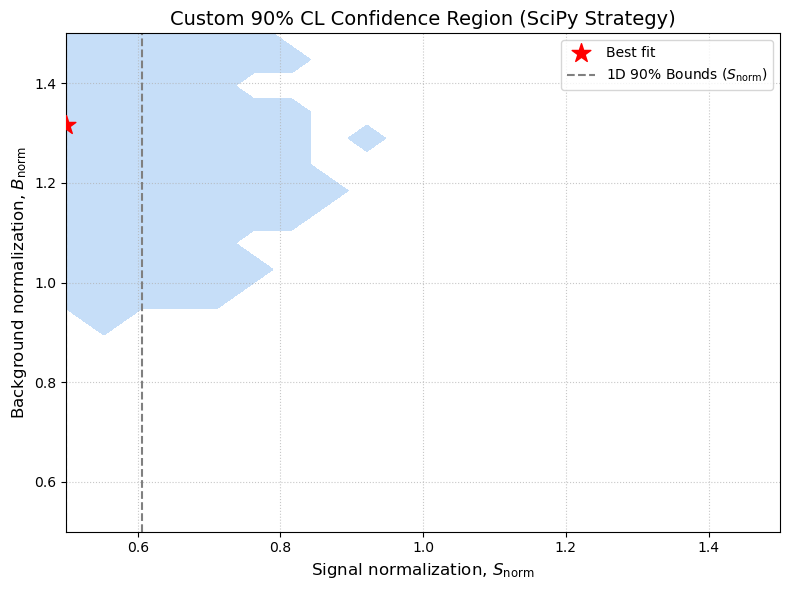

In [3]:
import os

import matplotlib.pyplot as plt
import numpy as np

# 1. Define paths to the output from Example 1 (using the scipy run)
base_dir = "fc_tutorial_output/compare_scipy"
json_path = os.path.join(base_dir, "fc_results.json")
npz_path = os.path.join(base_dir, "fc_results.npz") 

# 2. Extract Data from JSON
try:
    with open(json_path, "r") as f:
        fc_data = json.load(f)
        
    # The best fit is a list matching the order of param_names_3p
    best_fit = fc_data["best_fit"]
    bf_s_norm = best_fit[0]
    bf_b_norm = best_fit[1]
    
    # Extract the 90% CL 1D interval for S_norm using the generic 'param1' key
    s_norm_bounds_90 = fc_data["1d_intervals"]["param1"]["thresholds"]["0.9"]["interval_bounds"]
    
except FileNotFoundError:
    print(f"Error: Could not find {json_path}. Ensure Example 1 completed successfully.")

# 3. Extract 2D Acceptance Grid from NPZ
try:
    npz_data = np.load(npz_path)
    
    # Extract grid vectors and mask using the specific pair-naming schema 
    p1_vals = npz_data['2d_test_p1_p1p2'] 
    p2_vals = npz_data['2d_test_p2_p1p2']
    accepted_mask_90 = npz_data['2d_accepted_p1p2_0.9'] 
    
    # Generate the meshgrid corresponding to the evaluated points
    X, Y = np.meshgrid(p1_vals, p2_vals, indexing='ij')
    
    # 4. Generate the Custom Plot
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Plot the 2D acceptance region using contourf (0 = rejected, 1 = accepted)
    # The levels [0.5, 1.5] isolate the True (1) values.
    ax.contourf(X, Y, accepted_mask_90, levels=[0.5, 1.5], colors=['#a1c9f4'], alpha=0.6)
    
    # Overlay the best-fit point
    ax.scatter(bf_s_norm, bf_b_norm, color='red', marker='*', s=200, label='Best fit', zorder=5)
    
    # Overlay the 1D bounds as reference lines
    ax.axvline(s_norm_bounds_90[0], color='gray', linestyle='--', linewidth=1.5, label=r'1D 90% Bounds ($S_{\rm norm}$)')
    ax.axvline(s_norm_bounds_90[1], color='gray', linestyle='--', linewidth=1.5)
    
    # Formatting
    ax.set_xlabel(r"Signal normalization, $S_{\rm norm}$", fontsize=12)
    ax.set_ylabel(r"Background normalization, $B_{\rm norm}$", fontsize=12)
    ax.set_title("Custom 90% CL Confidence Region (SciPy Strategy)", fontsize=14)
    ax.legend(loc='upper right')
    ax.grid(True, linestyle=':', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print(f"Error: Could not find {npz_path}. Ensure compute_2D_intervals=True was set in Example 1.")
except KeyError:
    print(f"Key mismatch in NPZ file. Available keys are: {npz_data.files}")